In [2]:
import pandas as pd
import scipy.stats as stats
import numpy as np

In [3]:
countries = pd.read_csv("CountriesSD.csv")
summer = pd.read_csv("SummerSD.csv")
winter = pd.read_csv("WinterSD.csv")


In [4]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      201 non-null    int64  
 1   Country         201 non-null    object 
 2   Code            201 non-null    object 
 3   Population      196 non-null    float64
 4   GDP per Capita  176 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 8.0+ KB


In [5]:
#clean any missing values from each dataset
clean_countries = countries.dropna()

In [6]:
#clean any missing values from each dataset
clean_summer = summer.dropna()

In [7]:
clean_winter = winter.dropna()

In [8]:
clean_summer.head(5)

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
0,0,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,100M Freestyle,Gold,Hungary
1,1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria
2,2,1896,Athens,Aquatics,Swimming,Dimitrios Drivas,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,3,1896,Athens,Aquatics,Swimming,Ioannis Malokinis,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,4,1896,Athens,Aquatics,Swimming,Spiridon Chasapis,GRE,Men,100M Freestyle For Sailors,Silver,Greece


In [9]:
clean_countries.head(5)

,Unnamed: 0,Country,Code,Population,GDP per Capita
0,0,Afghanistan,AFG,32526562.0,594.323081
1,1,Albania,ALB,2889167.0,3945.217582
2,2,Algeria,ALG,39666519.0,4206.031232
5,5,Angola,ANG,25021974.0,4101.472152
6,6,Antigua and Barbuda,ANT,91818.0,13714.731962


In [10]:
# joining the clean version of summer to clean version of countries - one to many
join_sum_countries = clean_summer.merge(clean_countries, on="Country", how="left")

In [11]:
join_sum_countries.head()

,Unnamed: 0_x,Year,City,Sport,Discipline,Athlete,Code_x,Gender,Event,Medal,Country,Unnamed: 0_y,Code_y,Population,GDP per Capita
0,0,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,100M Freestyle,Gold,Hungary,82.0,HUN,9844686.0,12363.543460
1,1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria,11.0,AUT,8611088.0,43774.985174
2,2,1896,Athens,Aquatics,Swimming,Dimitrios Drivas,GRE,Men,100M Freestyle For Sailors,Bronze,Greece,72.0,GRE,10823732.0,18002.230578
3,3,1896,Athens,Aquatics,Swimming,Ioannis Malokinis,GRE,Men,100M Freestyle For Sailors,Gold,Greece,72.0,GRE,10823732.0,18002.230578
4,4,1896,Athens,Aquatics,Swimming,Spiridon Chasapis,GRE,Men,100M Freestyle For Sailors,Silver,Greece,72.0,GRE,10823732.0,18002.230578


In [12]:
# taking out unnecesary / repeat colums
join_sum_countries = join_sum_countries.drop(columns=["Unnamed: 0_x", "Unnamed: 0_y", "Code_y"])

In [13]:
join_sum_countries["GDP per Capita"].describe()

count     25142.000000
mean      36819.832226
std       19545.022998
min         277.068309
25%       17118.504200
50%       41313.313995
75%       56115.718426
max      101449.968168
Name: GDP per Capita, dtype: float64

<Axes: >

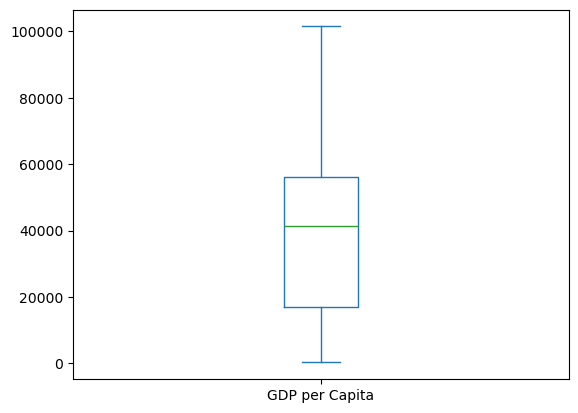

In [14]:
# visualize the distribution of GDP per Capita
join_sum_countries["GDP per Capita"].plot(kind="box")

In [16]:
# split joined data into upper half gdp and lower half gdp
high_GDP_winter = join_sum_countries[join_sum_countries["GDP per Capita"] >= 41313.313995]
low_GDP_winter = join_sum_countries[join_sum_countries["GDP per Capita"] < 41313.313995]

Null and Alternative Hypotheses:   
Null - medal count of countries with high GDP <= medal count of countries with low GDP
Alternative - medal count of countries with high GDP > medal count of countries with low GDP

In [17]:
high_GDP_winter.head(5)

,Year,City,Sport,Discipline,Athlete,Code_x,Gender,Event,Medal,Country,Population,GDP per Capita
1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria,8611088.0,43774.985174
9,1896,Athens,Aquatics,Swimming,Paul Neumann,AUT,Men,400M Freestyle,Gold,Austria,8611088.0,43774.985174
11,1896,Athens,Athletics,Athletics,Francis Lane,USA,Men,100M,Bronze,United States,321418820.0,56115.718426
13,1896,Athens,Athletics,Athletics,Thomas Burke,USA,Men,100M,Gold,United States,321418820.0,56115.718426
15,1896,Athens,Athletics,Athletics,Thomas Curtis,USA,Men,110M Hurdles,Gold,United States,321418820.0,56115.718426


In [22]:
# Making correct table for high GDP
medal_count_high = high_GDP_winter[high_GDP_winter["Medal"].notna()]
medal_count_high = medal_count_high.groupby("Country")["Medal"].count().reset_index()
medal_count_high.rename(columns={"Medal": "Total_Medals"}, inplace=True)

# Table for low GDP to perform statistical testing
medal_count_low = low_GDP_winter[low_GDP_winter["Medal"].notna()]
medal_count_low = medal_count_low.groupby("Country")["Medal"].count().reset_index()
medal_count_low.rename(columns={"Medal": "Total_Medals"}, inplace=True)

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value_two_sided = ttest_ind(
    medal_count_high["Total_Medals"],
    medal_count_low["Total_Medals"],
    equal_var=False  
)

# Convert to one-sided because we are trying to determine if high GDP medal count is higher
if t_stat > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1

print("t-statistic:", t_stat)
print("one-sided p-value:", p_value_one_sided)

t-statistic: 2.1529907068386867
one-sided p-value: 0.02328403144047401
